# TP – Le compromis biais-variance

**Binôme :** PAULA FONTENELE Amanda – DE BEM Pedro
**Fiche de paramètres n° :** ...

Ce notebook accompagne la partie 2 du sujet. Complétez les cellules marquées `# TODO` et répondez aux questions dans les cellules Markdown « Réponse ».

Règles :
- ne modifiez pas la cellule de paramètres, sauf pour y reporter les valeurs de **votre** fiche ;
- exécutez le notebook de haut en bas avant le rendu (*Kernel → Restart & Run All*) : les valeurs aléatoires dépendent de l'ordre d'exécution ;
- numérotez vos figures (`Fig. 1`, `Fig. 2`…) : la note de recul devra y renvoyer.

## 0. Paramètres et outils

In [36]:
# Valeurs de VOTRE fiche de paramètres
A     = 3.0    # fréquence de la sinusoïde
B     = 0.5    # pente de la tendance linéaire
SIGMA = 0.3    # écart-type du bruit
SEED  = 12345  # graine aléatoire

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})

rng = np.random.default_rng(SEED)
f = lambda x: np.sin(A * np.pi * x) + B * x
x_test = np.linspace(0, 1, 200)

def draw_dataset(n=30):
    """Tire un jeu d'entraînement de n points (x uniformes, bruit homoscédastique)."""
    x = rng.uniform(0, 1, n)
    y = f(x) + rng.normal(0, SIGMA, n)
    return x.reshape(-1, 1), y

def poly_model(degree):
    return make_pipeline(PolynomialFeatures(degree), LinearRegression())

def fit_predict(x, y, degree):
    model = poly_model(degree)
    model.fit(x, y)
    return model.predict(x_test.reshape(-1, 1))

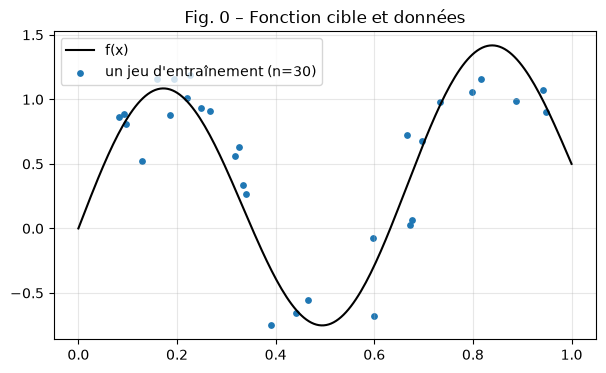

In [38]:
# Visualisation de la fonction cible et d'un jeu d'entraînement
x, y = draw_dataset(30)
plt.plot(x_test, f(x_test), "k", label="f(x)")
plt.scatter(x, y, s=15, label="un jeu d'entraînement (n=30)")
plt.title("Fig. 0 – Fonction cible et données"); plt.legend(); plt.show()

## Exercice 1 – Observer

Pour les degrés 1, 3 et 15, tirez 20 jeux de 30 points et superposez les 20 courbes prédites avec f (un sous-graphique par degré).

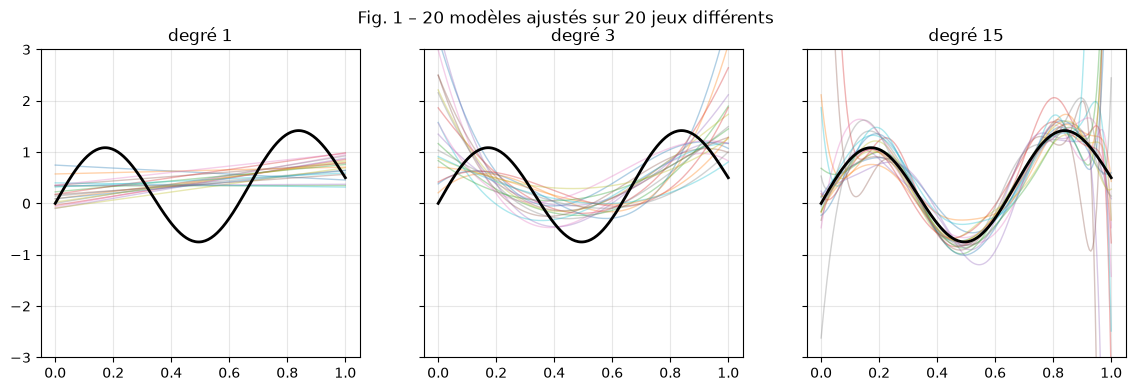

In [39]:
degrees = [1, 3, 15]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, d in zip(axes, degrees):
    # TODO : tirer 20 jeux, ajuster, tracer les 20 prédictions (fines, transparentes)
    for _ in range(20):
        x, y = draw_dataset(30)
        y_pred = fit_predict(x, y, d)
        ax.plot(x_test, y_pred, lw=1, alpha=0.35)
    ax.plot(x_test, f(x_test), "k", lw=2, label="f")
    ax.set_title(f"degré {d}"); ax.set_ylim(-3, 3)
fig.suptitle("Fig. 1 – 20 modèles ajustés sur 20 jeux différents"); plt.show()

**Réponse (2 phrases par degré) :**

- degré 1 : Faible variance car les 20 courbes de prédiction sont très proches les unes des autres. En revanche, le biais est élevé, car les prédictions restent relativement éloignées de la fonction cible.
- degré 3 : Courbes plus éloignées les unes des autres, ce qui traduit une augmentation de la variance. Cependant, les prédictions restent encore assez éloignées de la fonction cible, ce qui indique que le biais reste important. 
- degré 15 : On observe une variance très élevée, en particulier aux extrémités de l’intervalle, où les courbes présentent un comportement très instable. Concernant le biais, il est plus difficile de tirer une conclusion forte uniquement à partir de cette figure, à cause de cette forte instabilité. 

## Exercice 2 – Mesurer

Complétez la fonction `bias_variance`. Elle tire `M` jeux, ajuste un modèle par jeu et renvoie, **pour chaque point de `x_test`** :

- `bias2` : (moyenne des prédictions − f(x))² ;
- `var` : variance des prédictions autour de leur moyenne ;
- `noise` : variance du bruit en x ;
- `err` : erreur quadratique moyenne mesurée sur des **y bruités frais** (un nouveau y par modèle et par x).

La fonction est générique : elle servira aussi aux exercices 3, 4 et 6.

In [40]:
def bias_variance(fit_fn, draw_fn, M=200, noise_sd=lambda x: SIGMA * np.ones_like(x)):
    """fit_fn(x, y) -> prédictions sur x_test ; draw_fn() -> (x, y)."""
    preds = np.array([fit_fn(*draw_fn()) for _ in range(M)])   # forme (M, len(x_test))
    # TODO : calculer bias2, var, noise et err (tableaux de taille len(x_test))
    mean_pred = np.mean(preds, axis=0)
    bias2 = (mean_pred - f(x_test))**2
    var = np.mean((preds - mean_pred)**2, axis=0)
    noise = noise_sd(x_test)**2
    noise = noise_sd(x_test)**2
    y_fresh = f(x_test) + rng.normal(0, SIGMA, size=preds.shape)
    err = np.mean((y_fresh - preds)**2, axis=0)

    return bias2, var, noise, err

In [41]:
def sweep_degrees(n, degrees=range(0, 16), M=200, draw=None,
                  noise_sd=lambda x: SIGMA * np.ones_like(x)):
    """Renvoie un dict de tableaux (moyennés sur x_test) pour chaque degré."""
    draw = draw or (lambda: draw_dataset(n))
    res = {k: [] for k in ["bias2", "var", "noise", "err"]}
    for d in degrees:
        out = bias_variance(lambda x, y: fit_predict(x, y, d), draw, M=M, noise_sd=noise_sd)
        for k, v in zip(res, out):
            res[k].append(np.mean(v))
    return {k: np.array(v) for k, v in res.items()}

def plot_sweep(res, xs, title, xlabel="degré du polynôme", ax=None):
    ax = ax or plt.gca()
    ax.plot(xs, res["bias2"], "o-", label="biais²")
    ax.plot(xs, res["var"], "s-", label="variance")
    ax.plot(xs, res["err"], "k^-", label="erreur de test")
    ax.axhline(np.mean(res["noise"]), color="gray", ls="--", label="bruit σ²")
    ax.set_yscale("log"); ax.set_xlabel(xlabel); ax.set_title(title); ax.legend()

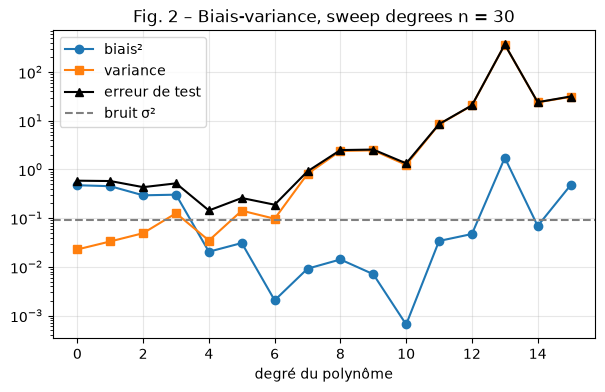

In [42]:
degrees = np.arange(0, 16)
# TODO : res30 = sweep_degrees(30) puis tracer avec plot_sweep (Fig. 2)
res30 = sweep_degrees(30)
plot_sweep(res30, degrees, "Fig. 2 – Biais-variance, sweep degrees n = 30")

In [ ]:
# TODO : vérifier biais² + variance + bruit ≈ erreur, degré par degré
# Afficher un tableau : degré | somme | erreur mesurée | écart relatif (%)
total_theorique = (res30["bias2"] + res30["var"] + res30["noise"])
erreur= res30["err"]
ecart_relatif = np.abs(total_theorique - erreur) / erreur
ecart_relatif_pct = 100 * ecart_relatif
print(f"{'degré':>6} | {'somme':>12} | {'erreur mesurée':>15} | {'écart relatif (%)':>18}")
print("-" * 62)

for d, somme, erreur, ecart in zip(
    degrees,
    total_theorique,
    erreur,
    ecart_relatif_pct
):
    print(f"{d:6d} | {somme:12.6f} | {erreur:15.6f} | {ecart:18.3f}")

 degré |        somme |  erreur mesurée |  écart relatif (%)
--------------------------------------------------------------
     0 |     0.586867 |        0.587793 |              0.158
     1 |     0.576276 |        0.577921 |              0.285
     2 |     0.433402 |        0.432936 |              0.108
     3 |     0.519537 |        0.518105 |              0.276
     4 |     0.145187 |        0.143842 |              0.935
     5 |     0.263253 |        0.259225 |              1.554
     6 |     0.189328 |        0.188741 |              0.311
     7 |     0.911693 |        0.915307 |              0.395
     8 |     2.504784 |        2.500406 |              0.175
     9 |     2.563801 |        2.559303 |              0.176
    10 |     1.331142 |        1.333046 |              0.143
    11 |     8.534207 |        8.523693 |              0.123
    12 |    20.709427 |       20.723871 |              0.070
    13 |   367.839874 |      367.891854 |              0.014
    14 |    24.049266 

**Réponse :** degré optimal trouvé, forme des courbes, origine de l'écart entre la somme et l'erreur mesurée.
Le degré optimal est 4 parce que c'est le plus petit erreur de test. Pour les faibles degrés, le biais est élevé et la variance faible, quand le degré augmente le biais diminue globalement tandis que la variance augmente fortement. 

La somme biais2 + variance + bruit est très proche de l’erreur mesurée, l'écart vient de l’estimation sur un nombre fini de simulations M=200 et des tirages aléatoires du bruit.

In [50]:
print("Écart relatif moyen :", np.mean(ecart_relatif_pct), "%")

Écart relatif moyen : 0.29841132534557024 %


## Exercice 3 – Faire varier n

Refaites l'exercice 2 pour n = 15, 30 et 200 (trois sous-graphiques côte à côte), puis donnez le degré optimal pour chaque n.

*Remarque : avec n = 15, les degrés élevés approchent l'interpolation ; l'échelle log est indispensable.*

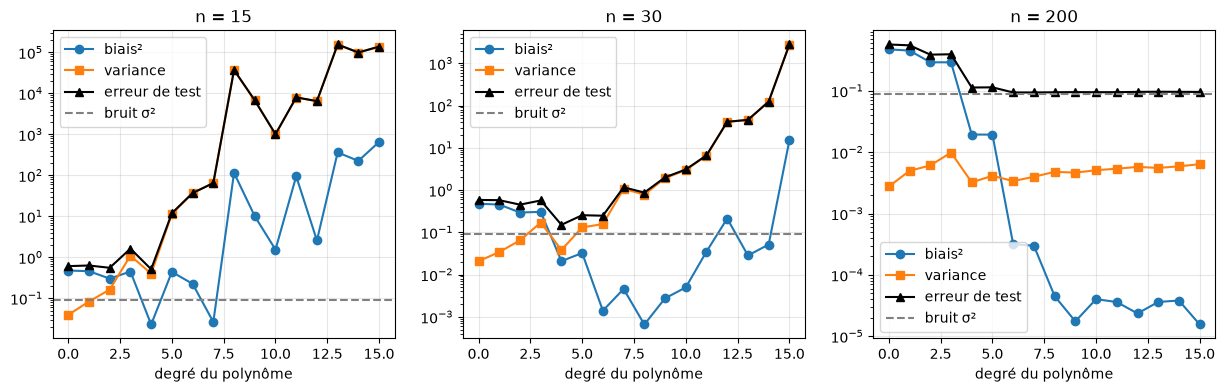

In [44]:
ns = [15, 30, 200]
results_n = {}
# TODO : pour chaque n, sweep_degrees(n), tracer (Fig. 3), afficher le degré optimal
for n in ns:
    results_n[n] = sweep_degrees(n)
    
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, n in zip(axes, ns):
    plot_sweep(
        results_n[n],
        degrees,
        f"n = {n}",
        ax=ax
    )

plt.show()

In [45]:
for n in ns:
    d_opt = degrees[np.argmin(results_n[n]["err"])]
    print(f"n = {n} : degré optimal = {d_opt}")

n = 15 : degré optimal = 4
n = 30 : degré optimal = 4
n = 200 : degré optimal = 6


**Réponse :** comment et pourquoi le degré optimal se déplace-t-il avec n ?
Avec plus de données les modèles avec plus de degrées deviennent plus stables donc leur variance diminue. On peut alors utiliser un degré plus élevé pour réduire davantage le biais sans provoquer autant de sur-apprentissage.

## Exercice 4 – Un autre modèle : k plus proches voisins

Faites varier k de 1 à 30 (n = 30) et tracez biais², variance et erreur en fonction de k.

In [46]:
ks = np.arange(1, 31)
# TODO : pour chaque k, bias_variance avec KNeighborsRegressor(n_neighbors=k) ; tracer (Fig. 4
def sweep_knn(n, ks=range(1, 31), M=200):
    res = {
        "bias2": [],
        "var": [],
        "noise": [],
        "err": []
    }
    for k in ks:
        def fit_knn(x, y):
            model = KNeighborsRegressor(n_neighbors=k)
            model.fit(x, y)
            return model.predict(x_test.reshape(-1, 1))
        out = bias_variance(
            fit_knn,
            lambda: draw_dataset(n),
            M=M
        )
        for key, values in zip(res, out):
            res[key].append(np.mean(values))
    return {
        key: np.array(values)
        for key, values in res.items()
    }

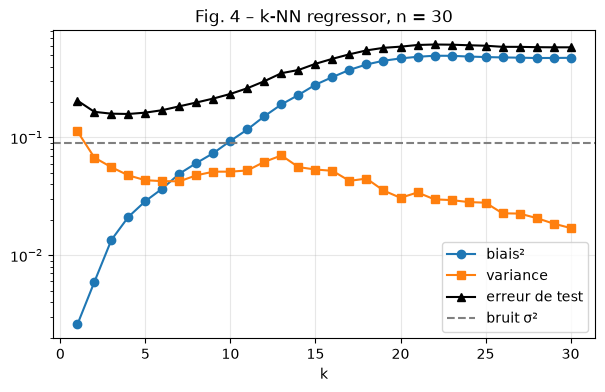

In [47]:
res_knn = sweep_knn(30, ks)

plot_sweep(
    res_knn,
    ks,
    "Fig. 4 – k-NN regressor, n = 30",
    xlabel="k"
)

plt.show()

**Réponse :** quel paramètre joue le rôle de la complexité, et dans quel sens ?
Le paramètre k joue le rôle de la complexité du modèle, mais dans le sens inverse parce que plus k est petit, plus le modèle est complexe. Un petit k donne un faible biais mais une forte variance, tandis qu’un grand k augmente le biais et réduit la variance.

## Exercice 5 – Sans connaître f

Sur **un seul** jeu de 30 points, choisissez le degré (0 à 12) par validation croisée à 5 plis. Répétez sur 50 jeux indépendants et tracez l'histogramme des degrés retenus.

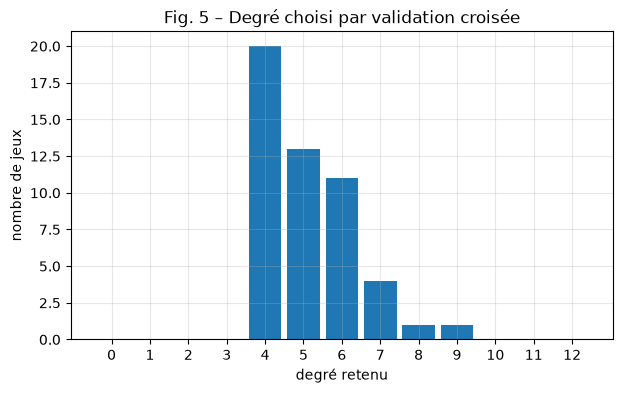

degré 4 : 20 fois
degré 5 : 13 fois
degré 6 : 11 fois
degré 7 : 4 fois
degré 8 : 1 fois
degré 9 : 1 fois


In [49]:
def degree_by_cv(x, y, degrees=range(0, 13)):
    # TODO : renvoyer le degré qui minimise l'erreur quadratique en validation croisée
    #        (KFold(5, shuffle=True, random_state=0), scoring="neg_mean_squared_error")
     cv = KFold(n_splits=5, shuffle=True, random_state=0)
     mse_cv = []
     for d in degrees:
        scores = cross_val_score(poly_model(d), x, y, cv=cv, scoring="neg_mean_squared_error")
        mse_cv.append(-np.mean(scores))

     degrees = np.array(list(degrees))

     return degrees[np.argmin(mse_cv)]

# TODO : appliquer à 50 jeux, histogramme (Fig. 5), afficher la répartition
selected_degrees = []

for _ in range(50):
    x, y = draw_dataset(30)
    d_opt = degree_by_cv(x, y)
    selected_degrees.append(d_opt)

selected_degrees = np.array(selected_degrees)

plt.hist( selected_degrees, bins=np.arange(-0.5, 13.5, 1), rwidth=0.85)
plt.xticks(np.arange(0, 13))
plt.xlabel("degré retenu")
plt.ylabel("nombre de jeux")
plt.title("Fig. 5 – Degré choisi par validation croisée")
plt.show()

values, counts = np.unique(selected_degrees, return_counts=True)

for d, count in zip(values, counts):
    print(f"degré {d} : {count} fois")

**Réponse :** le degré retenu est-il stable ? Que dit cette instabilité ?
Le degré choisi change selon le jeu de données, le degré 4 est choisi 26 fois sur 50 mais d’autres degrés apparaissent aussi. Cela montre qu’avec seulement 30 points bruités, le meilleur degré peut changer d’un jeu à l’autre. La validation croisée aide à choisir le modèle, mais le résultat dépend encore des données utilisées.

## Exercice 6 – Quand les hypothèses ne tiennent plus

Deux changements :
- les x d'entraînement suivent une loi **Beta(2, 5)** (peu de points près de x = 1) ;
- le bruit est **hétéroscédastique** : ε(x) ~ N(0, (SIGMA·(0,5 + 2x))²).

L'erreur reste évaluée sur la grille uniforme `x_test`.

1. Complétez `draw_dataset_shift` et `noise_sd_shift`.
2. Pour les degrés 1, 3 et 8 (n = 30), tracez biais² et variance **en fonction de x** (Fig. 6).
3. Refaites le balayage en degré et comparez le degré optimal à celui de l'exercice 2 (Fig. 7).

In [ ]:
def noise_sd_shift(x):
    return SIGMA * (0.5 + 2*x)

def draw_dataset_shift(n=30):
    # TODO : x ~ Beta(2, 5), bruit de sd noise_sd_shift(x)
    x = rng.beta(2, 5, n)
    y = (f(x) + rng.normal( 0, noise_sd_shift(x), n))
    return x.reshape(-1, 1), y

degré 1 : variance maximale à x = 1.000, valeur = 0.4839
degré 3 : variance maximale à x = 1.000, valeur = 75.6491
degré 8 : variance maximale à x = 1.000, valeur = 67334485.5452


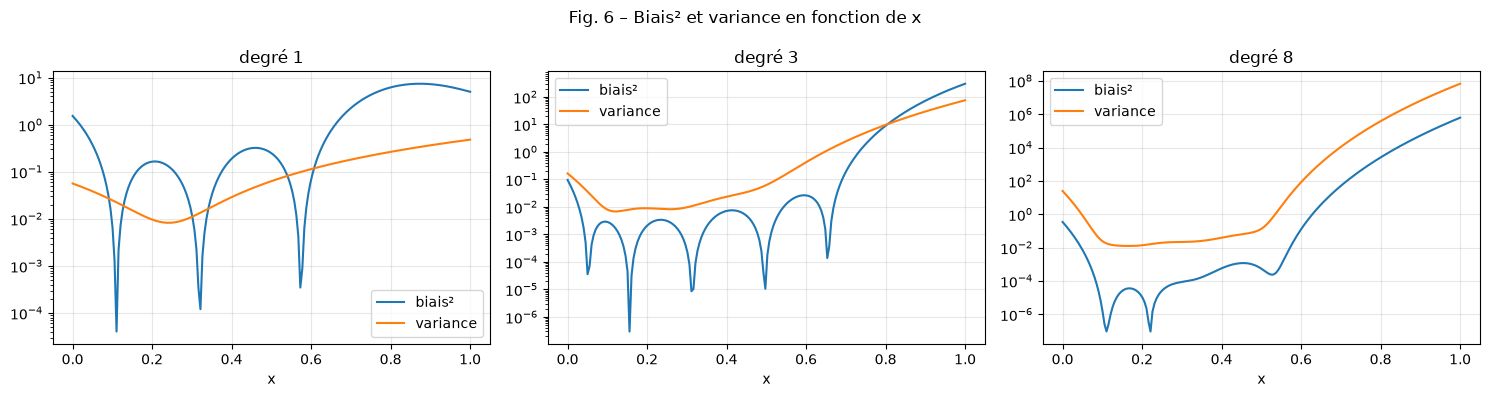

In [ ]:
# TODO : pour d in [1, 3, 8], bias_variance(..., draw_fn=draw_dataset_shift, noise_sd=noise_sd_shift)
#        tracer biais² et variance en fonction de x_test (échelle log), Fig. 6
#        afficher la zone de x où la variance est maximale et sa valeur
degrees_shift = [1, 3, 8]

fig, axes = plt.subplots(
1,
    3,
    figsize=(15, 4)
)

for ax, d in zip(axes, degrees_shift):

    bias2, var, noise, err = bias_variance(lambda x, y: fit_predict(x, y, d), draw_dataset_shift, M=200, 
    noise_sd=noise_sd_shift)

    ax.plot(x_test, bias2, label="biais²")
    ax.plot(x_test, var, label="variance")

    ax.set_yscale("log")
    ax.set_xlabel("x")
    ax.set_title(f"degré {d}")
    ax.legend()

    i_max = np.argmax(var)

    print(
        f"degré {d} : "
        f"variance maximale à x = {x_test[i_max]:.3f}, "
        f"valeur = {var[i_max]:.4f}"
    )

fig.suptitle(
    "Fig. 6 – Biais² et variance en fonction de x"
)

plt.tight_layout()
plt.show()

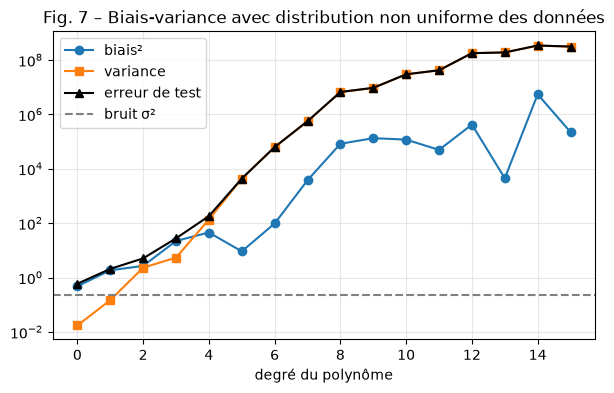

In [ ]:
# TODO : sweep_degrees(30, draw=..., noise_sd=...) puis Fig. 7 et comparaison avec res30
res_shift = sweep_degrees( 30, draw=lambda: draw_dataset_shift(30), noise_sd=noise_sd_shift)

plot_sweep(res_shift, degrees, "Fig. 7 – Biais-variance avec distribution non uniforme des données")
plt.show()

In [ ]:
d_opt_original = degrees[np.argmin(res30["err"])]

d_opt_shift = degrees[np.argmin(res_shift["err"])]

print("Degré optimal – cas initial :", d_opt_original)

print( "Degré optimal – cas modifié :", d_opt_shift)

Degré optimal – cas initial : 4
Degré optimal – cas modifié : 0


**Réponse :** où la variance se concentre-t-elle et pourquoi ? Le degré optimal change-t-il ? Quel est le bruit irréductible ici ?
La variance est surtout élevée près de \(x=1\), où il y a peu de points d’entraînement. Elle augmente aussi beaucoup quand le degré du modèle devient grand. Le degré optimal passe de 4 dans le cas initial à 0 dans ce nouveau cas. Le bruit n’est plus le même partout : il devient plus fort quand \(x\) augmente, mais la décomposition de l’erreur reste valable.

## Bonus – Régularisation Ridge

Au degré 15 (n = 30), faites varier α de 1e-6 à 1e2 (échelle log) et tracez biais² et variance en fonction de α. Pensez à standardiser les variables polynomiales avant Ridge.

In [ ]:
alphas = np.logspace(-6, 2, 17)
# TODO : make_pipeline(PolynomialFeatures(15), StandardScaler(), Ridge(alpha=a)) ; Fig. 8

## Récapitulatif des valeurs à reporter dans la note de recul

Complétez ce tableau à partir de vos sorties.

| Valeur | Résultat | Figure / cellule |
|---|---|---|
| Degré optimal, n = 15 / 30 / 200 | 4 / 4 / 7 | Fig. 3|
| Écart relatif moyen somme vs erreur (ex. 2) | 0,29 % | Ex. 2 – cellule du calcul de l’écart relatif |
| Répartition des degrés retenus par CV (ex. 5) | 2: 1, 4: 26, 5: 4, 6: 12, 7: 3, 8: 1, 9: 2, 10: 1 | Fig. 5 |
| Zone de x de variance maximale et ordre de grandeur (ex. 6) | près de x=1 jusqu’à environ 10^8 | Fig. 6 |